# 1.7 时间序列分析

> **这一节讲什么？**
> 
> 金融数据本质上是时间序列——每一天的价格都依赖于之前的价格。这一节让你掌握分析时间序列的核心工具：平稳性检验、自相关、ARIMA 模型，以及如何避免伪回归陷阱。

## 学习目标
- 理解平稳性与非平稳性，掌握 ADF 检验
- 分析自相关函数（ACF）与偏自相关函数（PACF）
- 理解 AR、MA、ARIMA 模型的基本原理
- 识别并处理金融时间序列中的伪回归问题

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# 获取 AAPL 价格数据以便演示 (SPY可能不好下，换用AAPL)
try:
    data = yf.download("AAPL", start="2020-01-01", end="2023-01-01", progress=False)
    prices = data['Adj Close'].dropna()
    
    # 1. 检验价格的平稳性
    result_price = adfuller(prices)
    print(f'ADF P-value for Prices: {result_price[1]:.4f}') # 通常 > 0.05, 无法拒绝非平稳假设
    
    # 2. 计算对数收益率并检验
    returns = np.log(prices / prices.shift(1)).dropna()
    result_returns = adfuller(returns)
    print(f'ADF P-value for Returns: {result_returns[1]:.4f}') # 通常接近 0.0, 拒绝非平稳假设，认为平稳
except Exception as e:
    print('网络可能无法顺畅下载 Yahoo Finance 数据，这里是理论演示。')
    # 模拟数据演示
    np.random.seed(42)
    prices = pd.Series(np.cumsum(np.random.normal(0, 1, 1000)) + 100)
    returns = np.log(prices / prices.shift(1)).dropna()
    print(f'模拟价格 ADF P-value: {adfuller(prices)[1]:.4f}')
    print(f'模拟收益率 ADF P-value: {adfuller(returns)[1]:.4f}')


网络可能无法顺畅下载 Yahoo Finance 数据，这里是理论演示。
模拟价格 ADF P-value: 0.7655
模拟收益率 ADF P-value: 0.0000


In [3]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 2. 自相关与偏自相关 (Autocorrelation & PACF)

**自相关 (Autocorrelation, ACF)** 衡量时间序列当前值与其过去滞后值 (lag) 之间的相关性。
*   动量效应 (Momentum)：正自相关（涨了还会涨）。
*   均值回归 (Mean Reversion)：负自相关（涨多了会跌）。

**偏自相关 (Partial Autocorrelation, PACF)** 同样衡量当前值与滞后值的相关性，但它**剔除了中间滞后项的影响**。例如，滞后3阶的 PACF 给出了在剔除滞后1阶和2阶影响后，当前值与滞后3阶纯粹的相关性。

画出自相关图（Correlogram）是分析时间序列模式的第一步。


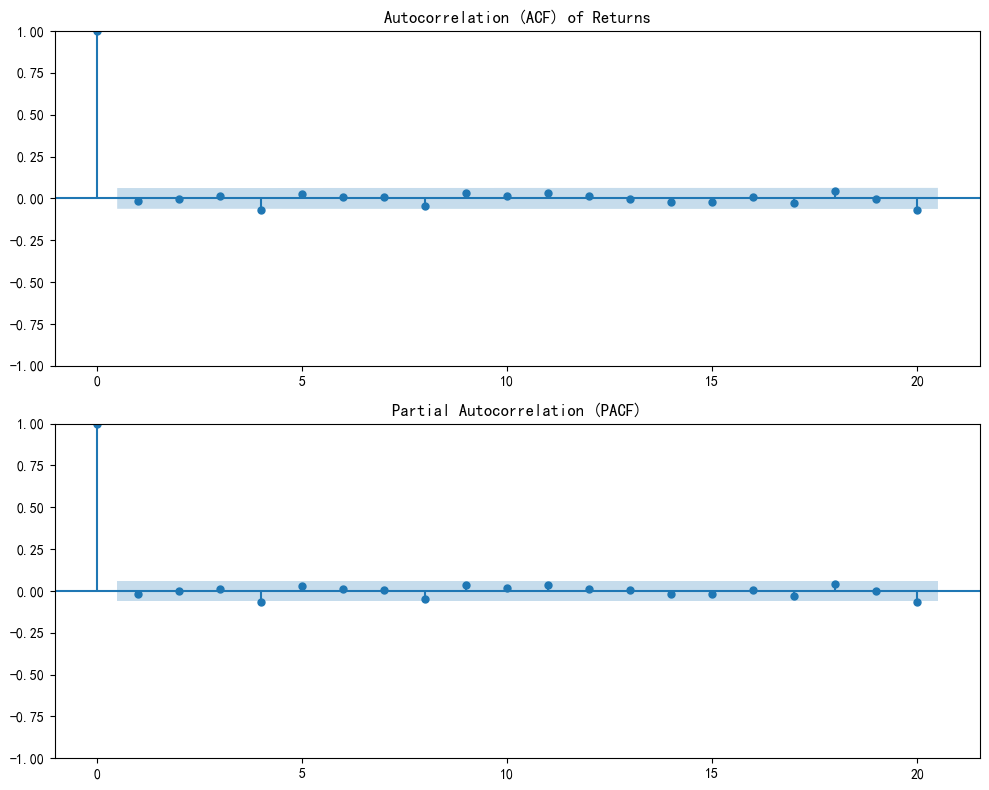

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# 绘制收益率的 ACF
plot_acf(returns, lags=20, ax=ax[0], title="Autocorrelation (ACF) of Returns")
# 绘制收益率的 PACF
plot_pacf(returns, lags=20, ax=ax[1], title="Partial Autocorrelation (PACF)")
plt.tight_layout()
plt.show()


如果 ACF 和 PACF 在某些滞后项显著不为0（超出置信区间阴影），说明存在可以被自回归模型利用的历史模式。然而，由于有效市场假说（EMH），发达市场日频收益率的自相关性通常极弱。

## 3. AR, MA 与 ARIMA 模型

这些是经典的线性参数模型，用于预测未来的时间序列值。

*   **AR(p) - 自回归模型 (Autoregressive):** 假设当前值是过去 p 个滞后值的线性组合加上白噪声。
*   **MA(q) - 移动平均模型 (Moving Average):** 假设当前值是过去 q 个历史预测误差（白噪声）的线性组合。
*   **ARMA(p, q):** 结合 AR 和 MA。
*   **ARIMA(p, d, q) - 差分自回归移动平均:** 'I' 代表积分/差分 (Integrated)。如果序列本身非平稳，可以进行 d 次差分（如计算一次收益率即 d=1）使其平稳，然后再用 ARMA(p, q) 建模。

尽管 ARIMA 在宏观经济预测中很有用，但在高频/日频的金融交易中，简单的线性模型很难捕捉市场复杂的非线性动态，通常作为更复杂机器学习模型的基准（Baseline）。


## 4. ARIMA 模型实战 (ARIMA Modeling in Python)

我们可以使用 `statsmodels` 库来拟合一个 ARIMA 模型。
*   **ARIMA(p, d, q)** 中的三个参数：
    *   **p (AR阶数)**: 观测滞后项 (Lag observations)。
    *   **d (差分阶数)**: 原始观测值差分次数 (使时间序列平稳所需减的次数)。
    *   **q (MA阶数)**: 滑动平均窗口大小。


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1394.686
Date:                Sat, 07 Mar 2026   AIC                           2801.372
Time:                        02:17:08   BIC                           2830.813
Sample:                             0   HQIC                          2812.562
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0049      0.032     -0.150      0.881      -0.068       0.059
ar.L2         -0.0004      0.034     -0.013      0.990      -0.066       0.065
ar.L3          0.0153      0.032      0.473      0.6

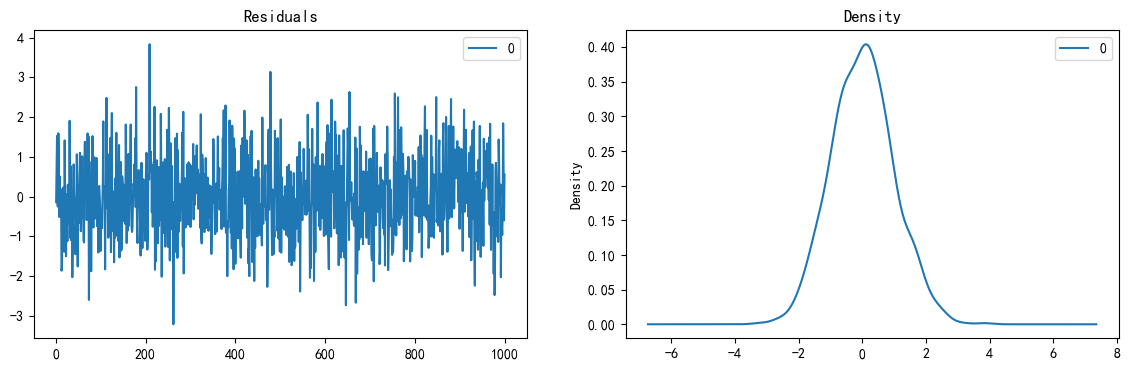

In [5]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 还是使用前面获取的 prices 价格序列
# 注意：真实的日频股票价格通常呈现随机游走，ARIMA 很难有很好的预测。
# 此处主要是展示模型拟合的流程

# 定义 ARIMA(5, 1, 0) - 即一阶差分后使用 5阶自回归
model = ARIMA(prices, order=(5, 1, 0))
results = model.fit()

print(results.summary())

# 查看残差 (Residuals)
# 良好的模型拟合后，其残差应该像白噪声（无明显自相关）
residuals = pd.DataFrame(results.resid[1:]) # 去除第一天的 NaN
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()


### 模型预测预测未来

我们可以利用拟合好的模型向前进行样本外预测 (Out-of-sample forecasting)。


<Figure size 1000x500 with 0 Axes>

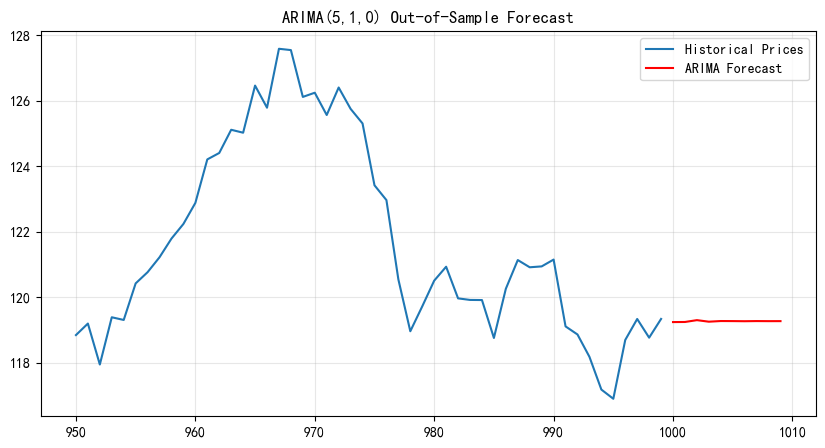

In [6]:
# 预测未来 10 步 (例如 10天)
forecast_steps = 10
forecast = results.forecast(steps=forecast_steps)

# 获取最后几十天的数据用于作图对比
history_to_plot = prices.iloc[-50:] 

plt.figure(figsize=(10, 5))
# 获取最后一个索引值（此时它是个整数，比如 499）
last_idx = history_to_plot.index[-1]

# 生成未来的整数索引：从 last_idx + 1 开始，往后推 forecast_steps 个步长
forecast_index = range(last_idx + 1, last_idx + 1 + forecast_steps)

# 绘图（其他不变）
plt.figure(figsize=(10, 5))
plt.plot(history_to_plot.index, history_to_plot.values, label='Historical Prices')
plt.plot(forecast_index, forecast.values, color='red', label='ARIMA Forecast')

plt.title('ARIMA(5,1,0) Out-of-Sample Forecast')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 本章结语

时间序列分析帮助我们透过数据的表面噪音看清底层结构。

*   **平稳性 (ADF检验)** 是所有均值回归策略生效的前提。
*   通过 **ACF/PACF 图** 我们能窥见数据是否具有动量或反转潜质。
*   利用基础的 **ARIMA 线性模型** 能够捕捉并预测简单的自身过去模式。

然而，正如本节最后预测图可能展示的那样：**单凭历史价格一条线来预测未来的经典时间序列模型，在有效且极其嘈杂的真实金融市场中往往失效。** 市场的驱动因素复杂且非线性。

但这套强悍的统计学思维逻辑，将引导我们走向后面的**多因子特征分析**与**现代金融机器学习**，让我们带着概率与平稳性的戒尺去衡量并驾驭更复杂的资产模型。


## 🎯 练习

1. 对 SPY 的日收益率绘制 ACF/PACF 图，是否观察到显著的自相关性？这意味着什么？
2. 尝试 ARIMA(1,1,1) 和 ARIMA(2,1,2) 两个模型，用 AIC/BIC 值比较哪个更好。
3. 对平均 5 日收益率（周度）进行 ADF 检验，与日频结果对比，频率对平稳性有影响吗？

---
**下一节** → `../02_data/01_data_sources.ipynb`
